In [106]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

import umap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os


In [107]:
# INPUT_FILE = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_second_big_overnight_run_10201/all_metrics_for_05_second_big_overnight_run_10201 copy 2.csv'
INPUT_FILE = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/81_all_animals_10_000_animal_15/all_metrics_for_81_all_animals_10_000_animal_15_combined_in_07_3_1.csv"
OUTPUT_DIR = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_second_big_overnight_run_10201/pca_results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Loading data from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

# Take only the rows where gamma < 1
df = df[df["gamma.1"] < 1]
# rename gamma.1 to gamma and eta.1 to eta
# df = df.rename(columns={"eta.1": "eta"})
# df = df.rename(columns={"gamma.1": "gamma"})

print([i for i in df.keys()])

# all keys: 'Unnamed: 0', 'eta', 'gamma', 'id', 'omega', 'eta', 'gamma', 'id.1', 'spectral_radius', 'spectral_gap', 'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency', 'nct_control_avg', 'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent', 'nct_control_n_nodes_10_percent', 'nct_energies_total', 'nct_energies_std', 'nct_energies_max', 'nct_energies_n_nodes_90_percent', 'nct_energies_n_nodes_50_percent', 'nct_energies_n_nodes_10_percent', 'synchronizability_eigenratio_eigenratio', 'synchronizability_eigenratio_lambda_2', 'synchronizability_eigenratio_lambda_N', 'algebraic_connectivity_nx', 'kuramoto_synchronization', 'community_synchronization_vulnerability_vulnerability', 'community_synchronization_vulnerability_n_communities', 'eta.2', 'gamma.2', 'id.2', 'kernel_rank_thresholded_and_summed_0.01', 'kernel_rank_max', 'kernel_rank_phase_of_lambda_max', 'kernel_rank_phase_diff_of_lambda_max_and_2nd', 'effective_dimensionality', 'eta.3', 'gamma.3', 'id.3', 'distance_relationship_type', 'preferential_relationship_type', 'generative_rule', 'num_iterations', 'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)', 'network_index', 'avg_communicability', 'global_efficiency.1', 'modularity', 'avg_clustering', 'avg_degree', 'density_bct', 'transitivity', 'avg_edge_distance', 'wiring_cost', 'char_path_length', 'richclub_n_edges', 'richclub_avg_length', 'mc_mean', 'mc_std', 'h_params_spectral_radius', 'h_params_input_scaling', 'h_params_train_len', 'h_params_n_runs', 'h_params_n_lags', 'h_params_test_len', 'h_params_leak_rate', 'h_params_bias', 'h_params_n_transient', 'h_params_random_state', 'mc_0', 'mc_1', 'mc_2', 'mc_3', 'mc_4', 'mc_5', 'mc_6', 'mc_7', 'mc_8', 'mc_9', 'mc_10', 'mc_11', 'mc_12', 'mc_13', 'mc_14', 'mc_15', 'mc_16', 'mc_17', 'mc_18', 'mc_19', 'mc_20', 'mc_21', 'mc_22', 'mc_23', 'mc_24', 'mc_25', 'mc_26', 'mc_27', 'mc_28', 'mc_29', 'mc_30', 'mc_31', 'mc_32', 'mc_33', 'mc_34', 'mc_35', 'mc_36', 'mc_37', 'mc_38', 'mc_39', 'mc_40', 'mc_41', 'mc_42', 'mc_43', 'mc_44', 'mc_45', 'mc_46', 'mc_47', 'mc_48', 'mc_49'
# 'Unnamed: 0', 'id', 'id.1', 'eta.2', 'gamma.2', 'id.2', 'eta.3', 'gamma.3', 'id.3', 'distance_relationship_type', 'preferential_relationship_type', 'generative_rule', 'num_iterations', 'network_index', 'global_efficiency.1', 'h_params_spectral_radius', 'h_params_input_scaling', 'h_params_train_len', 'h_params_n_runs', 'h_params_n_lags', 'h_params_test_len', 'h_params_leak_rate', 'h_params_bias', 'h_params_n_transient', 'h_params_random_state', 

Loading data from /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/81_all_animals_10_000_animal_15/all_metrics_for_81_all_animals_10_000_animal_15_combined_in_07_3_1.csv...
['Unnamed: 0', 'eta', 'gamma', 'id', 'omega', 'eta.1', 'gamma.1', 'id.1', 'spectral_radius', 'spectral_gap', 'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency', 'nct_control_avg', 'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent', 'nct_control_n_nodes_10_percent', 'nct_energies_total', 'nct_energies_std', 'nct_energies_max', 'nct_energies_n_nodes_90_percent', 'nct_energies_n_nodes_50_percent', 'nct_energies_n_nodes_10_percent', 'synchronizability_eigenratio_eigenratio', 'synchronizability_eigenratio_lambda_2', 'synchronizability_eigenratio_lambda_N', 'algebraic_connectivity_nx', 'kuramoto_synchronization', 'community_synchronization_vulnerability_vulnerability', 'community_synchronization_vulnerabilit

In [108]:


# Columns to exclude from PCA but keep for analysis
meta_cols = ['eta', 'gamma']

# Columns to generally exclude (because e.g. they are strings or hparams)
remove_cols = ['Unnamed: 0', 'id', 'id.1', "eta.1", "gamma.1", 'eta.2', 'gamma.2', 'id.2', 'eta.3', 'gamma.3', 'id.3', 'distance_relationship_type', 'preferential_relationship_type', 'generative_rule', 'num_iterations', 'network_index', 'global_efficiency.1', 'h_params_spectral_radius', 'h_params_input_scaling', 'h_params_train_len', 'h_params_n_runs', 'h_params_n_lags', 'h_params_test_len', 'h_params_leak_rate', 'h_params_bias', 'h_params_n_transient', 'h_params_random_state'] 
# 'id', 'distance_relationship_type', 'preferential_relationship_type', 'generative_rule', 'num_iterations', 'network_index', 'h_params_spectral_radius','h_params_input_scaling','h_params_train_len','h_params_n_runs','h_params_n_lags','h_params_test_len','h_params_leak_rate','h_params_bias','h_params_n_transient','h_params_random_state']    

# Separate features and metadata
df_meta = df[meta_cols]
df_features = df.drop(columns=meta_cols + remove_cols)

# Actually only keep columns of interest
selected_feature_cols = [
    'omega', 'spectral_radius', 'spectral_gap', 'global_efficiency', # 'diffusion_efficiency', 
    'propagation_efficiency', 
    'nct_control_avg', 'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent',
    'nct_control_n_nodes_50_percent', # 'nct_control_n_nodes_10_percent', 
    'nct_energies_total', 'nct_energies_std', 'nct_energies_max',# 'nct_energies_n_nodes_90_percent', 
    'nct_energies_n_nodes_50_percent', 
    # 'nct_energies_n_nodes_10_percent',
    # 'synchronizability_eigenratio_eigenratio', 
    'synchronizability_eigenratio_lambda_2', 'synchronizability_eigenratio_lambda_N', 'algebraic_connectivity_nx', 
    #  'kuramoto_synchronization', # 'community_synchronization_vulnerability_vulnerability', 
    'community_synchronization_vulnerability_n_communities', 'kernel_rank_thresholded_and_summed_0.01', 'kernel_rank_max', # 'kernel_rank_phase_of_lambda_max', 
    'effective_dimensionality',
    'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)', 'avg_communicability', 'modularity', 'avg_clustering', 'avg_degree', 'density_bct', 'transitivity', 'avg_edge_distance', 'wiring_cost', 'char_path_length', 'richclub_n_edges', 'richclub_avg_length', 'mc_15']
df_features = df_features[selected_feature_cols]

# Handle infinite values and missing values
print("Checking for infinite and missing values...")
df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
    
if df_features.isnull().values.any():
    print("Warning: Missing or infinite values found. Filling with mean.")
    df_features = df_features.fillna(df_features.mean())

Checking for infinite and missing values...


In [109]:
print([i for i in df_features.keys()])

# ['omega', 'spectral_radius', 'spectral_gap', 'global_efficiency', # 'diffusion_efficiency', 
#  'propagation_efficiency', 
#  'nct_control_avg', 'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent',
#  'nct_control_n_nodes_50_percent', # 'nct_control_n_nodes_10_percent', 
#  'nct_energies_total', 'nct_energies_std', 'nct_energies_max',# 'nct_energies_n_nodes_90_percent', 
#  'nct_energies_n_nodes_50_percent', 
#  # 'nct_energies_n_nodes_10_percent',
#  # 'synchronizability_eigenratio_eigenratio', 
#  'synchronizability_eigenratio_lambda_2', 'synchronizability_eigenratio_lambda_N', 'algebraic_connectivity_nx', 
# #  'kuramoto_synchronization', # 'community_synchronization_vulnerability_vulnerability', 
#  'community_synchronization_vulnerability_n_communities', 'kernel_rank_thresholded_and_summed_0.01', 'kernel_rank_max', # 'kernel_rank_phase_of_lambda_max', 
#  'effective_dimensionality',
#  'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)', 'avg_communicability', 'modularity', 'avg_clustering', 'avg_degree', 'density_bct', 'transitivity', 'avg_edge_distance', 'wiring_cost', 'char_path_length', 'richclub_n_edges', 'richclub_avg_length', 'mc_15']

['omega', 'spectral_radius', 'spectral_gap', 'global_efficiency', 'propagation_efficiency', 'nct_control_avg', 'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent', 'nct_energies_total', 'nct_energies_std', 'nct_energies_max', 'nct_energies_n_nodes_50_percent', 'synchronizability_eigenratio_lambda_2', 'synchronizability_eigenratio_lambda_N', 'algebraic_connectivity_nx', 'community_synchronization_vulnerability_n_communities', 'kernel_rank_thresholded_and_summed_0.01', 'kernel_rank_max', 'effective_dimensionality', 'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)', 'avg_communicability', 'modularity', 'avg_clustering', 'avg_degree', 'density_bct', 'transitivity', 'avg_edge_distance', 'wiring_cost', 'char_path_length', 'richclub_n_edges', 'richclub_avg_length', 'mc_15']


In [110]:
df_features

,omega,spectral_radius,spectral_gap,global_efficiency,propagation_efficiency,nct_control_avg,nct_control_std,nct_control_max,nct_control_n_nodes_90_percent,nct_control_n_nodes_50_percent,...,avg_clustering,avg_degree,density_bct,transitivity,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_15
0,0.868540,10.790553,4.526122,0.493401,0.600794,1.124497,0.050621,1.329391,89.0,48.0,...,0.111578,9.9,0.1,0.113020,37.636887,18630.259766,2.238990,39.0,31.911318,0.053834
1,0.840283,10.843961,4.724999,0.493889,0.602148,1.123773,0.053327,1.345429,89.0,48.0,...,0.526181,9.9,0.1,0.979083,34.645004,17149.277344,1.127016,190.0,32.462368,0.001668
2,0.824207,10.809524,4.616051,0.492138,0.600005,1.124175,0.051017,1.290502,89.0,48.0,...,0.544831,9.9,0.1,0.982911,38.926540,19268.636719,1.034188,190.0,36.602890,0.003697
3,0.845834,10.893861,4.631854,0.492306,0.592384,1.123287,0.054869,1.337309,89.0,48.0,...,0.212492,9.9,0.1,0.192110,32.010143,15845.021484,2.310909,63.0,22.275448,0.058883
4,0.861271,10.763813,4.728872,0.493535,0.607122,1.124585,0.049966,1.260332,89.0,48.0,...,0.106365,9.9,0.1,0.099153,36.333340,17985.003906,2.229899,36.0,41.654697,0.053506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,0.751004,28.156921,23.156921,0.105253,0.049173,1.140677,0.208713,1.514898,88.0,43.0,...,0.319532,9.9,0.1,0.415427,27.299267,13513.136719,2.110329,111.0,23.882023,0.019062
9995,0.460989,26.060091,15.946485,0.121515,0.050909,1.132357,0.195895,1.530142,88.0,43.0,...,0.626977,9.9,0.1,0.945280,36.021782,17830.781250,1.152709,190.0,35.338989,0.004927
9996,0.653544,28.000000,20.000000,0.100000,0.048596,1.140090,0.214347,1.475443,88.0,43.0,...,0.169275,9.9,0.1,0.171829,41.694809,20638.929688,2.291111,47.0,44.034664,0.056101
9997,0.583383,30.051781,27.008690,0.108384,0.049463,1.148703,0.220211,1.488836,88.0,42.0,...,0.112166,9.9,0.1,0.110628,39.356823,19481.626953,2.232929,34.0,36.933445,0.046569


In [111]:

# Scale the features
print("Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# Perform PCA
print("Performing PCA...")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

# Combine with metadata
df_final = pd.concat([df_meta, df_pca], axis=1)

# Save scores
scores_path = os.path.join(OUTPUT_DIR, 'pca_scores.csv')
df_final.to_csv(scores_path, index=False)
print(f"PCA scores saved to {scores_path}")

# Save loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=pca_cols, 
    index=df_features.columns
)
loadings_path = os.path.join(OUTPUT_DIR, 'pca_loadings.csv')
loadings.to_csv(loadings_path)
print(f"PCA loadings saved to {loadings_path}")


Scaling features...
Performing PCA...
PCA scores saved to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_second_big_overnight_run_10201/pca_results/pca_scores.csv
PCA loadings saved to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_second_big_overnight_run_10201/pca_results/pca_loadings.csv


In [112]:
# List the explained variance ratios for PC1 
explained_variance_path = os.path.join(OUTPUT_DIR, 'pca_explained_variance.csv')
explained_variance = pd.DataFrame({
    'Principal Component': pca_cols,
    'Explained Variance Ratio': pca.explained_variance_ratio_
})
explained_variance # .to_csv(explained_variance_path, index=False)
# print(f"PCA explained variance ratios saved to {explained_variance_path}")

,Principal Component,Explained Variance Ratio
0,PC1,5.146983e-01
1,PC2,1.943187e-01
2,PC3,9.040262e-02
3,PC4,7.085454e-02
4,PC5,2.858244e-02
5,PC6,1.815522e-02
6,PC7,1.594069e-02
7,PC8,1.254703e-02
8,PC9,1.180897e-02
9,PC10,7.628386e-03


In [113]:
# List which variables contribute most to PC1
loading_scores = pd.Series(pca.components_[0], index=df_features.columns)
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)
top_10_variables = sorted_loading_scores.head(10).index.values
print("Top 10 variables contributing to PC1:")
for var in top_10_variables:
    print(var)
    
# List which variables contribute most to PC2
loading_scores_pc2 = pd.Series(pca.components_[1], index=df_features.columns)
sorted_loading_scores_pc2 = loading_scores_pc2.abs().sort_values(ascending=False)
top_10_variables_pc2 = sorted_loading_scores_pc2.head(10).index.values
print("Top 10 variables contributing to PC2:")
for var in top_10_variables_pc2:
    print(var)

Top 10 variables contributing to PC1:
nct_control_std
nct_control_n_nodes_50_percent
effective_dimensionality
nct_energies_std
propagation_efficiency
spectral_radius
kernel_rank_max
global_efficiency
nct_energies_total
kernel_rank_thresholded_and_summed_0.01
Top 10 variables contributing to PC2:
transitivity
richclub_n_edges
mc_15
char_path_length
avg_communicability
avg_clustering
MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)
avg_edge_distance
wiring_cost
richclub_avg_length


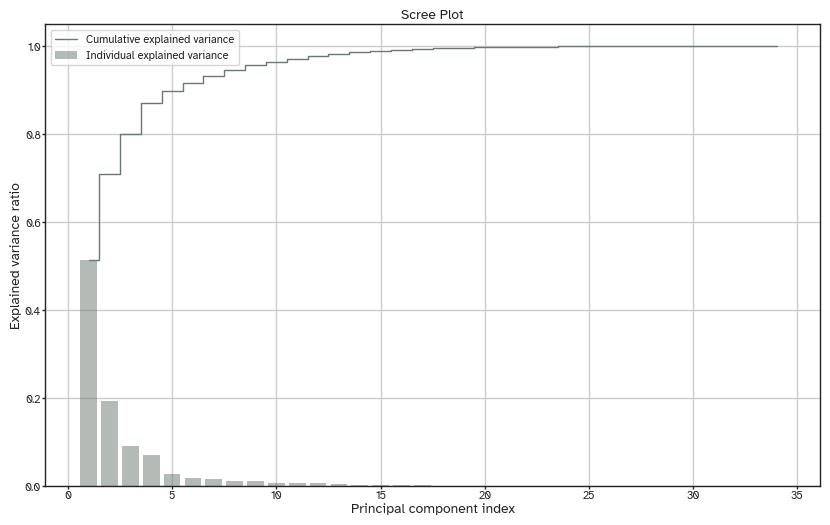

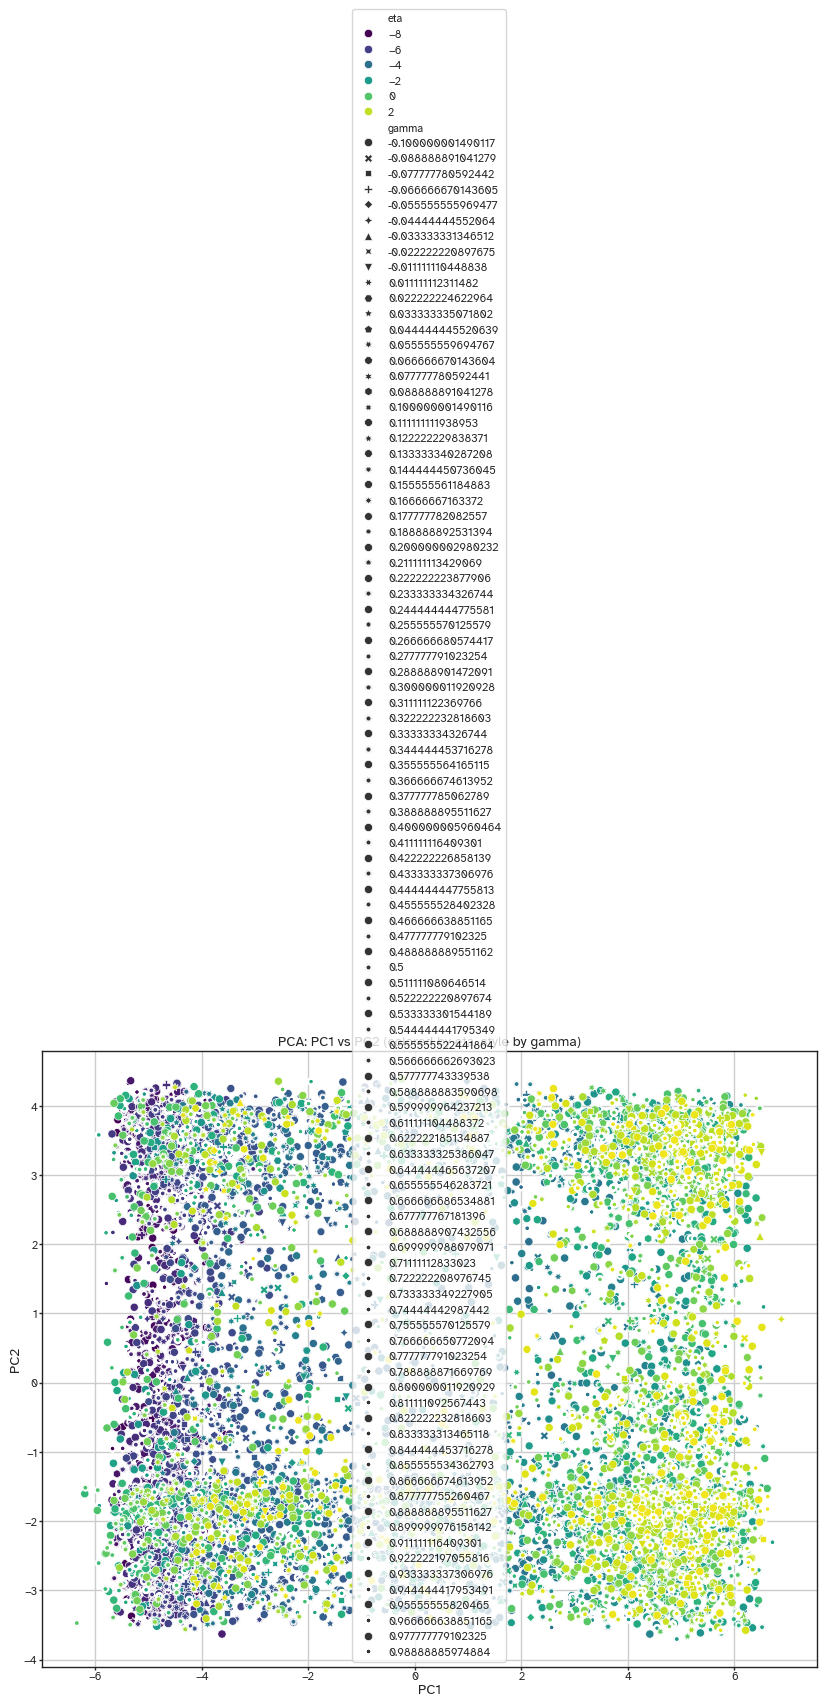

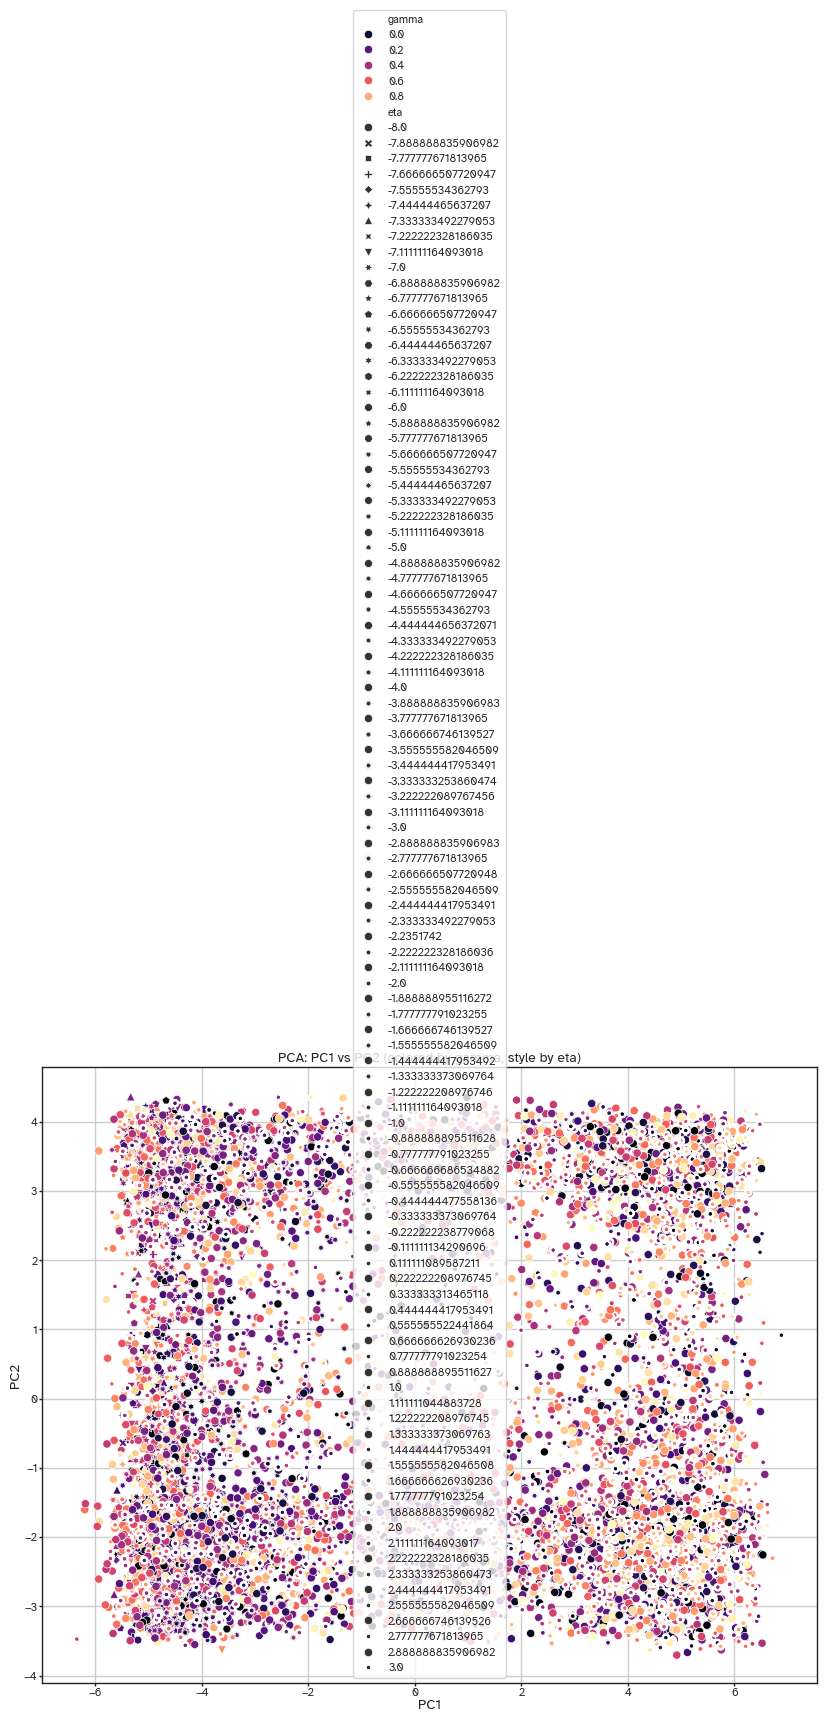

In [114]:

# --- Visualizations ---

# 1. Scree Plot
plt.figure(figsize=(10, 6))
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.grid(True)
scree_path = os.path.join(OUTPUT_DIR, 'pca_scree_plot.png')
# plt.savefig(scree_path)
# print(f"Scree plot saved to {scree_path}")
plt.show()

# 2. PC1 vs PC2 Scatter Plot (colored by eta)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_final, x='PC1', y='PC2', hue='eta', palette='viridis', style='gamma')
plt.title('PCA: PC1 vs PC2 (colored by eta, style by gamma)')
plt.grid(True)
scatter_path = os.path.join(OUTPUT_DIR, 'pca_scatter_plot.png')
# plt.savefig(scatter_path)
# print(f"Scatter plot saved to {scatter_path}")
plt.show()

# 3. PC1 vs PC2 Scatter Plot (colored by gamma)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_final, x='PC1', y='PC2', hue='gamma', palette='magma', style='eta')
plt.title('PCA: PC1 vs PC2 (colored by gamma, style by eta)')
plt.grid(True)
scatter_gamma_path = os.path.join(OUTPUT_DIR, 'pca_scatter_plot_gamma.png')
# plt.savefig(scatter_gamma_path)
# print(f"Scatter plot (gamma) saved to {scatter_gamma_path}")
# plt.close()
plt.show()

In [115]:
df_comb = pd.concat([df_final, df[["mc_15"]]], axis=1)
df_comb

,eta,gamma,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,mc_15
0,-8.0,-0.022222,-4.243947,-1.961138,1.276016,0.749458,-0.119670,0.995169,-1.503807,0.177080,...,-0.028059,0.042474,-0.024520,0.021554,-1.590265e-07,1.237442e-12,-3.508786e-13,-1.498616e-12,1.027258e-12,0.053834
1,-8.0,0.022222,-4.621562,3.222100,-1.006088,1.227144,-1.699184,0.703455,0.019514,0.631563,...,0.069740,0.068326,0.022772,-0.005718,-4.220691e-08,3.166053e-13,-8.943924e-14,-3.818965e-13,2.730654e-13,0.001668
2,-8.0,0.011111,-4.992083,3.695973,-1.190769,1.270841,1.572937,0.915067,0.083876,-0.097842,...,-0.025846,0.038049,-0.020448,0.002414,1.334204e-07,-1.039077e-12,2.957992e-13,1.246532e-12,-8.221269e-13,0.003697
3,-8.0,-0.100000,-5.129382,-2.462908,-0.497832,1.323961,-0.175292,-0.438215,-0.085960,0.605668,...,0.043800,0.028283,-0.009646,0.009421,-9.687066e-08,7.536717e-13,-2.139273e-13,-9.072724e-13,5.998604e-13,0.058883
4,-8.0,-0.033333,-4.928719,-1.877547,1.613331,1.173169,-0.008014,0.804824,-0.106915,-0.236412,...,-0.050561,-0.044489,0.012628,0.045081,-1.336023e-07,1.040143e-12,-2.976392e-13,-1.252320e-12,8.563151e-13,0.053506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9599,NaN,NaN,5.563684,-3.294404,-1.361540,0.651745,-0.200755,0.367829,1.082461,-0.748111,...,0.075966,0.037096,-0.008680,0.040249,-7.461075e-08,5.741476e-13,-1.613226e-13,-6.996335e-13,4.875751e-13,NaN
9607,NaN,NaN,-3.463445,-2.630237,-0.123732,-0.119577,-0.122492,0.035891,-0.512563,0.198554,...,0.073878,-0.032026,0.078419,0.006714,-1.327539e-07,1.031986e-12,-2.882972e-13,-1.256191e-12,8.765645e-13,NaN
9699,NaN,NaN,6.161430,-1.344056,-2.136143,2.671004,-0.625199,-1.247827,-0.054694,0.147081,...,0.084143,-0.005813,-0.008457,-0.013442,-1.210282e-08,9.741233e-14,-2.761460e-14,-1.123753e-13,6.663302e-14,NaN
9707,NaN,NaN,-2.821959,-3.404103,-1.305901,-0.454564,-0.044758,0.620422,-1.007860,1.509310,...,0.052719,-0.047085,0.036404,-0.013952,2.812148e-08,-2.475837e-13,6.179351e-14,3.385755e-13,-3.348570e-13,NaN


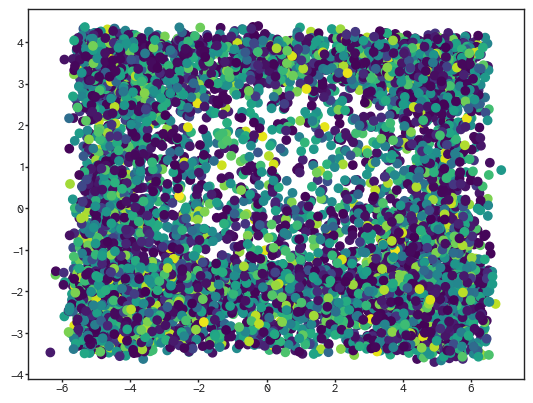

In [116]:
plt.scatter(df_comb['PC1'], df_comb['PC2'], c=df_comb['mc_15'], cmap='viridis')

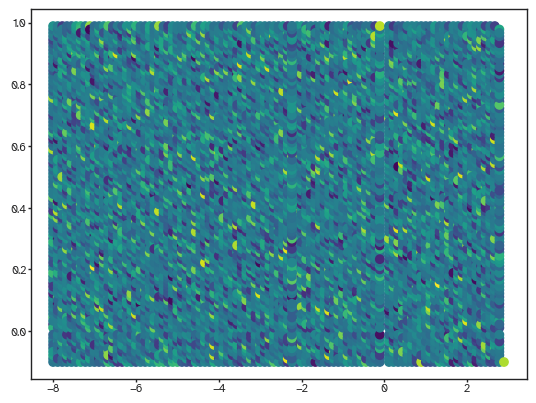

In [117]:
plt.scatter(df_final["eta"], df_final["gamma"], c=df_final["PC5"], cmap='viridis')

In [118]:
from vizman import viz
viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

cmap = default_cmaps["topological_map"] # bw_hb"]  # metric_purple_beige"]

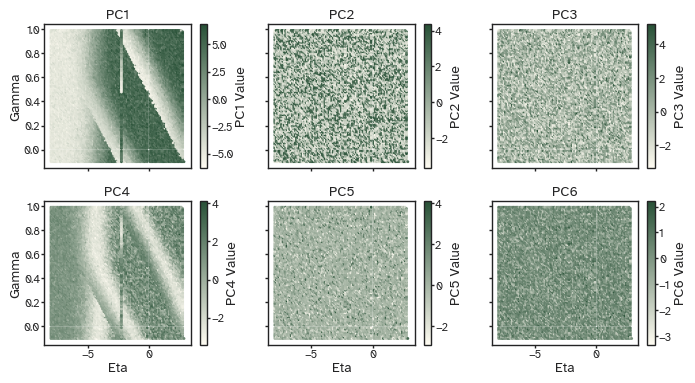

In [119]:
# plot the first 6 PCs against eta and gamma (shape: 2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(viz.cm_to_inch((18, 10))), sharex=True, sharey=True)
for i in range(6): 
    ax = axes[i // 3, i % 3]
    sc = ax.scatter(df_final["eta"], df_final["gamma"], c=df_final[f"PC{i+1}"], s=1, cmap=cmap.reversed())
    ax.set_title(f'PC{i+1}')
    if i % 3 == 0: 
        ax.set_ylabel('Gamma')
    if i // 3 == 1: 
        ax.set_xlabel('Eta')
    plt.colorbar(sc, ax=ax, label=f'PC{i+1} Value')
plt.tight_layout()
plt.show()

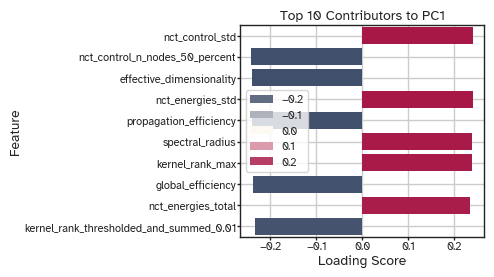

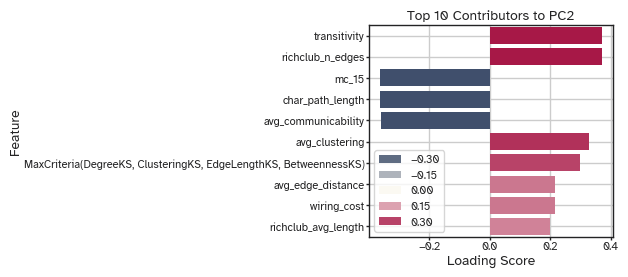

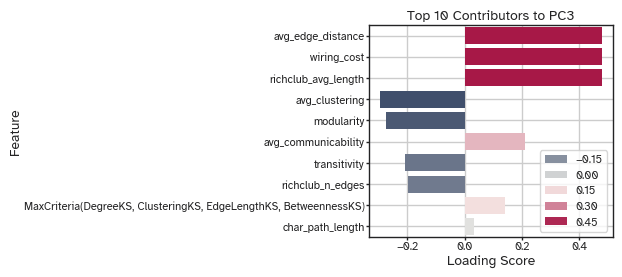

In [120]:
# Visualize the top contributors to the three first PCs

# Convert colormap to discrete colors
cmap = default_cmaps["nb_bw_dr"]
dark_green = "#275036"
colors = [cmap(i / 9) for i in range(10)]  # 10 colors for 10 bars


for pc_index in range(3):
    
    pc_num = pc_index + 1
    loading_scores = pd.Series(pca.components_[pc_index], index=df_features.columns)
    sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)
    top_variables = sorted_loading_scores.head(10).index.values
    
    plt.figure(figsize=(viz.cm_to_inch((8, 7))))
    sns.barplot(x=loading_scores[top_variables].values, y=top_variables, 
                palette=cmap, 
                hue=loading_scores[top_variables].values
                ) # , c=dark_green) # palette=dark_green) # coolwarm')
    plt.title(f'Top 10 Contributors to PC{pc_num}')
    plt.xlabel('Loading Score')
    plt.ylabel('Feature')
    plt.grid(True)
    plt.show()

In [121]:
print([i for i in df_final.keys()])

['eta', 'gamma', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34']


In [122]:
df_final


,eta,gamma,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34
0,-8.0,-0.022222,-4.243947,-1.961138,1.276016,0.749458,-0.119670,0.995169,-1.503807,0.177080,...,-0.004090,-0.028059,0.042474,-0.024520,0.021554,-1.590265e-07,1.237442e-12,-3.508786e-13,-1.498616e-12,1.027258e-12
1,-8.0,0.022222,-4.621562,3.222100,-1.006088,1.227144,-1.699184,0.703455,0.019514,0.631563,...,0.061644,0.069740,0.068326,0.022772,-0.005718,-4.220691e-08,3.166053e-13,-8.943924e-14,-3.818965e-13,2.730654e-13
2,-8.0,0.011111,-4.992083,3.695973,-1.190769,1.270841,1.572937,0.915067,0.083876,-0.097842,...,-0.070371,-0.025846,0.038049,-0.020448,0.002414,1.334204e-07,-1.039077e-12,2.957992e-13,1.246532e-12,-8.221269e-13
3,-8.0,-0.100000,-5.129382,-2.462908,-0.497832,1.323961,-0.175292,-0.438215,-0.085960,0.605668,...,0.020536,0.043800,0.028283,-0.009646,0.009421,-9.687066e-08,7.536717e-13,-2.139273e-13,-9.072724e-13,5.998604e-13
4,-8.0,-0.033333,-4.928719,-1.877547,1.613331,1.173169,-0.008014,0.804824,-0.106915,-0.236412,...,0.103875,-0.050561,-0.044489,0.012628,0.045081,-1.336023e-07,1.040143e-12,-2.976392e-13,-1.252320e-12,8.563151e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9599,NaN,NaN,5.563684,-3.294404,-1.361540,0.651745,-0.200755,0.367829,1.082461,-0.748111,...,0.040883,0.075966,0.037096,-0.008680,0.040249,-7.461075e-08,5.741476e-13,-1.613226e-13,-6.996335e-13,4.875751e-13
9607,NaN,NaN,-3.463445,-2.630237,-0.123732,-0.119577,-0.122492,0.035891,-0.512563,0.198554,...,0.041320,0.073878,-0.032026,0.078419,0.006714,-1.327539e-07,1.031986e-12,-2.882972e-13,-1.256191e-12,8.765645e-13
9699,NaN,NaN,6.161430,-1.344056,-2.136143,2.671004,-0.625199,-1.247827,-0.054694,0.147081,...,0.031473,0.084143,-0.005813,-0.008457,-0.013442,-1.210282e-08,9.741233e-14,-2.761460e-14,-1.123753e-13,6.663302e-14
9707,NaN,NaN,-2.821959,-3.404103,-1.305901,-0.454564,-0.044758,0.620422,-1.007860,1.509310,...,0.074790,0.052719,-0.047085,0.036404,-0.013952,2.812148e-08,-2.475837e-13,6.179351e-14,3.385755e-13,-3.348570e-13
